# Deep Learning Fashion MNIST


## Libraries

In [ ]:
# installing keras-tuner
!pip install keras-tuner --upgrade

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 4.6 MB/s eta 0:00:00


In [ ]:
import gc
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
import seaborn as sns
import keras_tuner as kt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

from sklearn.metrics import confusion_matrix
from tensorflow.keras import backend as K # Importing Keras backend (by default it is Tensorflow)
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Input, Conv2D, Dense, Dropout, Flatten, MaxPool2D , BatchNormalization # Layers to be used for building our model
from tensorflow.keras.models import Model # The class used to create a model
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.random import set_seed
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve, auc, f1_score
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import train_test_split

## Define the Function for Learning Curves

In [ ]:
# define the function for plotting the learning curves
def plot_history(hs, epochs, metric):
    print()
    fig = plt.figure(figsize=(9, 7))
    plt.style.use('dark_background')
    plt.rcParams['figure.figsize'] = [15, 8]
    plt.rcParams['font.size'] = 10
    plt.clf()
    for label in hs:
        plt.plot(hs[label].history[metric], label='{0:s} train {1:s}'.format(label, metric), linewidth=2)
        plt.plot(hs[label].history['val_{0:s}'.format(metric)], label='{0:s} validation {1:s}'.format(label, metric), linewidth=2)
    x_ticks = np.arange(0, epochs + 1,4)
    x_ticks [0] += 1
    plt.xticks(x_ticks)
    plt.ylim((0, 1))
    plt.xlabel('Epochs')
    plt.ylabel('Loss' if metric=='loss' else 'Accuracy')
    plt.legend()
    plt.show()

## Clean up Function

In [ ]:
# define the function for cleaning up
def clean_up(model):
    K.clear_session()
    del model
    gc.collect()

##Report Function

In [ ]:
# define the report function
def report(history_model, model_eval, model):

  print("Train Loss     : {0:.5f}".format(history_model.history['loss'][-1]))
  print("Validation Loss: {0:.5f}".format(history_model.history['val_loss'][-1]))
  print("Test Loss      : {0:.5f}".format(model_eval[0]))
  print("---")
  print("Train Accuracy     : {0:.5f}".format(history_model.history['accuracy'][-1]))
  print("Validation Accuracy: {0:.5f}".format(history_model.history['val_accuracy'][-1]))
  print("Test Accuracy      : {0:.5f}".format(model_eval[1]))

  print(f"\nPrecision, recall, F1 scores for each class (train set)")
  print(classification_report(Y_train, np.round(model.predict(X_train)).astype("int32")))
  print(f"\nPrecision, recall, F1 scores for each class (validation set)")
  print(classification_report(Y_dev, np.round(model.predict(X_dev)).astype("int32")))
  print(f"\nPrecision, recall, F1 scores for each class (test set)")
  print(classification_report(Y_test, np.round(model.predict(X_test)).astype("int32")))

  predictions = model.predict(X_test)
  y_pred = np.argmax(predictions, axis= 1)
  y_true=np.argmax(Y_test, axis= 1)
  cm = confusion_matrix(y_true, y_pred)
  labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
  class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

  fig = plt.figure(figsize=(8,6))
  ax= plt.subplot()
  sns.heatmap(cm, annot=True, ax = ax, fmt = 'g')
  ax.set_xlabel('Predicted', fontsize=20)
  ax.xaxis.set_label_position('bottom')
  plt.xticks(rotation=90)
  ax.xaxis.set_ticklabels(class_names, fontsize = 10)
  ax.xaxis.tick_bottom()
  ax.set_ylabel('True', fontsize=20)
  ax.yaxis.set_ticklabels(class_names, fontsize = 10)
  plt.yticks(rotation=0)
  plt.title('Confusion Matrix Plot', fontsize=20)
  plt.show()

## MLP


#### Data Importing & Preprocessing
**Task**: The task at hand is to identify the type of fashion item given an image representation.

**Data**:
- The dataset consists of grayscale images of fashion items, each measuring 28x28 pixels.
- To use a Multi-Layer Perceptron (MLP) for classification, we need to reshape the images into a flattened format.
- The pixel values in the dataset range from 0 to 255, so we apply normalization to scale them down to the range of 0 to 1.

In [ ]:
# loading the data
classes = 10
(X_train_dev, y_train_dev), (X_test, y_test) = fashion_mnist.load_data()

# splitting the data
X_train, X_dev, y_train, y_dev = train_test_split(X_train_dev, y_train_dev, test_size=0.1, random_state=7)

# print the results
print("Train Images shape:", X_train.shape)
print("Test Images shape:", X_test.shape)

# Change the label names
Label_name_dict = {
 0: "T-shirt/top",
 1: "Trouser",
 2: "Pullover",
 3: "Dress",
 4: "Coat",
 5: "Sandal",
 6: "Shirt",
 7: "Sneaker",
 8: "Bag",
 9: "Ankle boot"
}

4422102/4422102 [==============================] - 1s 0us/step
Train Images shape: (54000, 28, 28)
Test Images shape: (10000, 28, 28)


Bag


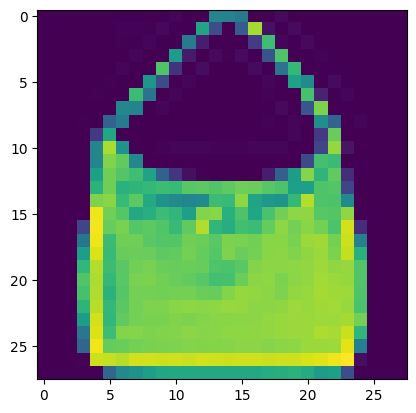

In [ ]:
# print a sample of images
plt.imshow(X_train[2])

# print the corresponding class
print(Label_name_dict[y_train[2]])

Ankle boot


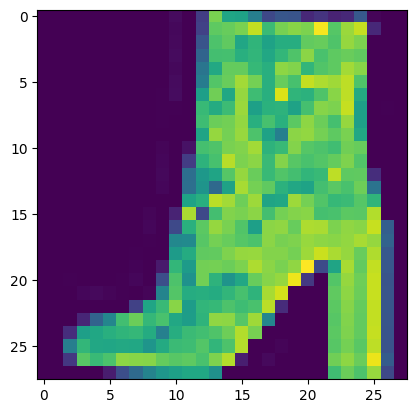

In [ ]:
# print a sample of images
plt.imshow(X_train[7])

# print the corresponding class
print(Label_name_dict[y_train[7]])

In [ ]:
# Print the number of images per category per data set

print("For train (before splitting)\n"+"----------------------------")

for i in np.unique(y_train_dev,return_counts=True)[0]:
  print(Label_name_dict[i], "count:",np.unique(y_train_dev,return_counts=True)[1][i])
print("")

print("For train set\n"+"-------------")

for i in np.unique(y_train,return_counts=True)[0]:
  print(Label_name_dict[i], "count:",np.unique(y_train,return_counts=True)[1][i])
print("")

print("For validation set\n"+"------------------")
for i in np.unique(y_dev,return_counts=True)[0]:
  print(Label_name_dict[i], "count:",np.unique(y_dev,return_counts=True)[1][i])
print("")

print("For test set\n"+"------------")
for i in np.unique(y_test,return_counts=True)[0]:
  print(Label_name_dict[i], "count:",np.unique(y_test,return_counts=True)[1][i])

For train (before splitting)
----------------------------
T-shirt/top count: 6000
Trouser count: 6000
Pullover count: 6000
Dress count: 6000
Coat count: 6000
Sandal count: 6000
Shirt count: 6000
Sneaker count: 6000
Bag count: 6000
Ankle boot count: 6000

For train set
-------------
T-shirt/top count: 5373
Trouser count: 5425
Pullover count: 5413
Dress count: 5381
Coat count: 5399
Sandal count: 5431
Shirt count: 5386
Sneaker count: 5407
Bag count: 5385
Ankle boot count: 5400

For validation set
------------------
T-shirt/top count: 627
Trouser count: 575
Pullover count: 587
Dress count: 619
Coat count: 601
Sandal count: 569
Shirt count: 614
Sneaker count: 593
Bag count: 615
Ankle boot count: 600

For test set
------------
T-shirt/top count: 1000
Trouser count: 1000
Pullover count: 1000
Dress count: 1000
Coat count: 1000
Sandal count: 1000
Shirt count: 1000
Sneaker count: 1000
Bag count: 1000
Ankle boot count: 1000


#### Data Flattening

In [ ]:
# reshaping the data sets
X_train = X_train.reshape(54000, 784)
X_dev = X_dev.reshape(6000, 784)
X_test = X_test.reshape(10000, 784)
X_train_dev = X_train_dev.reshape(60000, 784)

# changing the data types
X_train = X_train.astype('float32')
X_dev = X_dev.astype('float32')
X_test = X_test.astype('float32')
X_train_dev = X_train_dev.astype('float32')

# normalizatio
X_train /= 255
X_dev /= 255
X_test /= 255
X_train_dev /= 255

# creating one hot veftors for the classes
Y_train = to_categorical(y_train, classes)
Y_dev = to_categorical(y_dev, classes)
Y_test = to_categorical(y_test, classes)
Y_train_dev = to_categorical(y_train_dev, classes)

#### MLP creation
1. We create an MLP as a class in order to pass the optimizer as an argument later as well as passing a boolean argument for the dropout layers.
2. In the architecture of our functional MLP we hypertune:
    - The number of hidden layers, their activation function, the number of units and their kernel initializer.
    - The number of the dropout rate of every hidden layer.
    - The value of the learning rate.
    - The value of the batch size.
    - The kernel initializer of the output layer.


In [ ]:
# Creating a class for MLP tuning
class MyHyperModel(kt.HyperModel):
    # users' initial values
    def __init__(self,layer_dropout,optimizer):
        self.layer_dropout = layer_dropout
        self.optimizer = optimizer

    # Define the MLP achitecture
    def build(self, hp):
        np.random.seed(1966) # Define the seed for numpy to have reproducible experiments.
        set_seed(1908) # Define the seed for Tensorflow to have reproducible experiments.

        # Define the input layer.
        input = Input(
            shape=(784,),
            name='Input'
        )

        x = input
        # Define the remaining hidden layers.
        for i in range(hp.Int('hidden layers',2,5)):
            x = Dense(
                 units=hp.Choice('units of Dense-{0:d}'.format(i + 1),[128,256,512]),
                 kernel_initializer=hp.Choice('kernel_initializer',['glorot_uniform','glorot_normal']), # weights initialization
                 activation=hp.Choice('activation_function',['swish','tanh',"gelu"]),
                 name='Hidden-{0:d}'.format(i + 1)
            )(x)

            # Dropout (TRUE or FALSE)
            if self.layer_dropout:
               x = Dropout(
                    rate=hp.Float('dropout_rate-{0:d}'.format(i + 1),0,0.6,step=0.2),
                    name='Dropout-{0:d}'.format(i + 1))(x)

        # Define the output layer.
        output = Dense(
            units=classes,
            kernel_initializer=hp.Choice('kernel_initializer',['glorot_uniform','glorot_normal',"he_normal"]),
            activation=hp.Choice('output_activation_function',['softmax']),
            name='Output'
        )(x)

        # Define the model and train it.
        model = Model(inputs=input, outputs=output)
        model.compile(optimizer=self.optimizer(learning_rate=hp.Float("lr",0.00001,0.001)), loss='categorical_crossentropy', metrics=['accuracy'])
        return model
    # Batch size tuning
    def fit(self, hp, model, *args, **kwargs):
        return model.fit(
            *args,
            batch_size=hp.Choice("batch_size", [16, 32,64,128,256]),
            **kwargs,
        )

#### MLP Using Adam as Optimizer


In [ ]:
# define the tuner
tuner_adam = kt.BayesianOptimization( # using bayesian optimizer
    MyHyperModel(True,Adam),
    objective="val_accuracy",
    max_trials=10,
    overwrite=True
)

In [ ]:
# searching for the best model
tuner_adam.search(X_train, Y_train, epochs=100, callbacks=[ReduceLROnPlateau(monitor='val_accuracy', patience=2, cooldown=2),tf.keras.callbacks.EarlyStopping('val_accuracy', patience=5,restore_best_weights=True)],
                  validation_data=(X_dev,Y_dev))

Trial 10 Complete [00h 01m 25s]
val_accuracy: 0.8976666927337646

Best val_accuracy So Far: 0.9023333191871643
Total elapsed time: 00h 25m 49s


In [ ]:
# summary of the best model
tuner_adam.results_summary(1)

Results summary
Results in ./untitled_project
Showing 1 best trials
Objective(name="val_accuracy", direction="max")

Trial 03 summary
Hyperparameters:
hidden layers: 2
units of Dense-1: 256
kernel_initializer: glorot_uniform
activation_function: swish
dropout_rate-1: 0.0
units of Dense-2: 256
dropout_rate-2: 0.4
output_activation_function: softmax
lr: 0.0009180232547480061
units of Dense-3: 128
dropout_rate-3: 0.0
units of Dense-4: 512
dropout_rate-4: 0.2
batch_size: 32
Score: 0.9023333191871643


In [ ]:
# define the model with the best parameters after tuning process
best_hps_mlp_adam = tuner_adam.get_best_hyperparameters(num_trials=1)[0]

# Build the model with the optimal hyperparameters and train it on the data for 100 epochs
model_adam_mlp = tuner_adam.hypermodel.build(best_hps_mlp_adam)
#model_adam_mlp.save("adam_mlp_model")
history_adam_mlp = model_adam_mlp.fit(X_train, Y_train, epochs=100,batch_size=32, callbacks=[ReduceLROnPlateau(monitor='val_accuracy', patience=2, cooldown=2),tf.keras.callbacks.EarlyStopping('val_accuracy', patience=5,restore_best_weights=True)], validation_data=(X_dev,Y_dev))


Epoch 1/100
1688/1688 [==============================] - 8s 4ms/step - loss: 0.5035 - accuracy: 0.8181 - val_loss: 0.3853 - val_accuracy: 0.8570 - lr: 9.1802e-04
Epoch 2/100
1688/1688 [==============================] - 6s 4ms/step - loss: 0.3684 - accuracy: 0.8635 - val_loss: 0.3517 - val_accuracy: 0.8673 - lr: 9.1802e-04
Epoch 3/100
1688/1688 [==============================] - 7s 4ms/step - loss: 0.3269 - accuracy: 0.8781 - val_loss: 0.3391 - val_accuracy: 0.8757 - lr: 9.1802e-04
Epoch 4/100
1688/1688 [==============================] - 6s 4ms/step - loss: 0.3026 - accuracy: 0.8854 - val_loss: 0.3251 - val_accuracy: 0.8785 - lr: 9.1802e-04
Epoch 5/100
1688/1688 [==============================] - 7s 4ms/step - loss: 0.2847 - accuracy: 0.8939 - val_loss: 0.3312 - val_accuracy: 0.8810 - lr: 9.1802e-04
Epoch 6/100
1688/1688 [==============================] - 6s 4ms/step - loss: 0.2670 - accuracy: 0.8994 - val_loss: 0.3509 - val_accuracy: 0.8702 - lr: 9.1802e-04
Epoch 7/100
1688/1688 [=====

In [ ]:
# It can be used to reconstruct the model identically.
#model_adam_mlp = keras.models.load_model("adam_mlp_model")
# summary of the best model
model_adam_mlp.summary()
#history_adam_mlp = model_adam_mlp.fit(X_train, Y_train, epochs=50,batch_size=128,callbacks=[ReduceLROnPlateau(monitor='val_accuracy', patience=2, cooldown=2),tf.keras.callbacks.EarlyStopping('val_accuracy', patience=5,restore_best_weights=True)], validation_data=(X_val,Y_val))

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 784)]             0         
                                                                 
 Hidden-1 (Dense)            (None, 256)               200960    
                                                                 
 Dropout-1 (Dropout)         (None, 256)               0         
                                                                 
 Hidden-2 (Dense)            (None, 256)               65792     
                                                                 
 Dropout-2 (Dropout)         (None, 256)               0         
                                                                 
 Output (Dense)              (None, 10)                2570      
                                                                 
Total params: 269,322
Trainable params: 269,322
Non-trainab

In [ ]:
val_acc_per_epoch_mlp_adam = history_adam_mlp.history['val_accuracy']
best_epoch_mlp_adam = val_acc_per_epoch_mlp_adam.index(max(val_acc_per_epoch_mlp_adam)) + 1
print('Best epoch: %d' % (best_epoch_mlp_adam,))

Best epoch: 21


In [ ]:
# evaluation of the final model
model_adam_mlp_eval = model_adam_mlp.evaluate(X_test, Y_test)

# cleaning up
clean_up(model=model_adam_mlp)

313/313 [==============================] - 1s 2ms/step - loss: 0.3387 - accuracy: 0.9008


#### MLP Using Adam | Results
- We developed an MLP using the Adam optimizer. In general, Adam's algorithm is obvious that it perfoms better than the respective MLP attempt that uses the SGD optimizer.
  

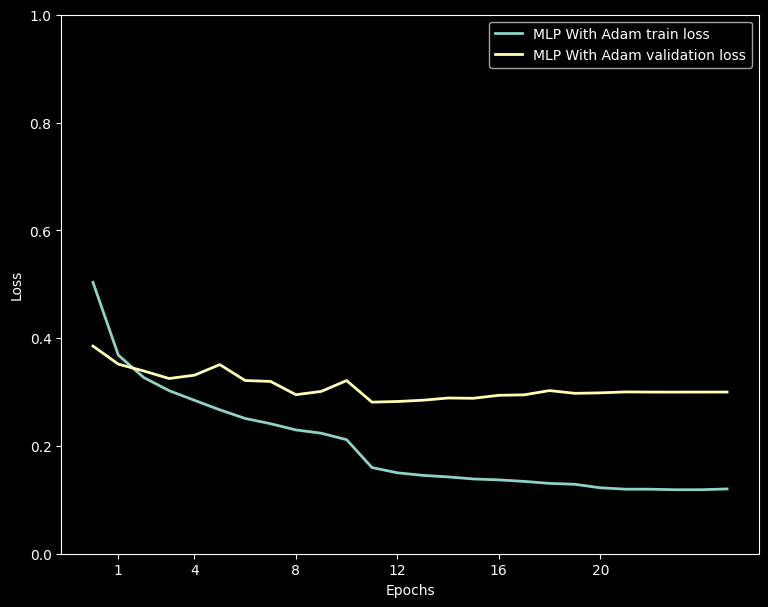

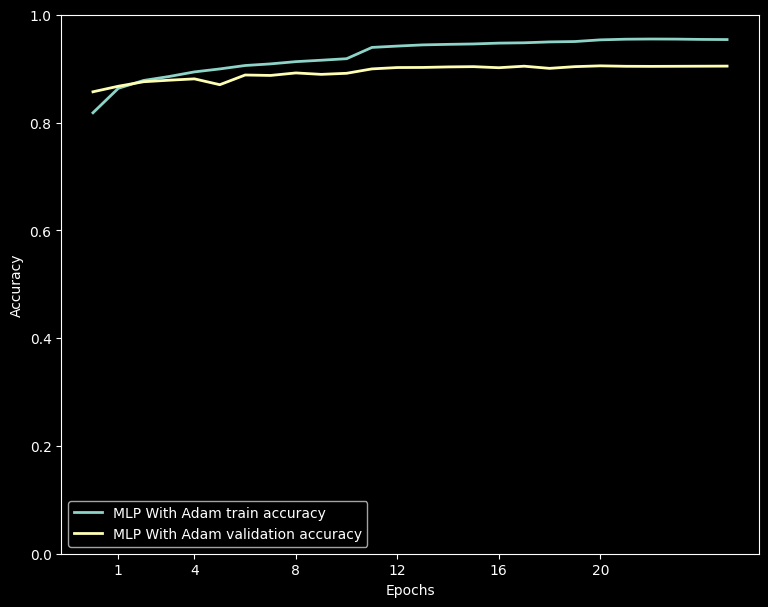

In [ ]:
# Plot train and validation error per epoch.9+
plot_history(hs={'MLP With Adam': history_adam_mlp}, epochs=best_epoch_mlp_adam, metric='loss')
plot_history(hs={'MLP With Adam': history_adam_mlp}, epochs=best_epoch_mlp_adam, metric='accuracy')

**Learning curves**
- On the first plot we can see that the training loss curve is stabilizing after some epochs. Also, the validation loss curve seem to have more ups and downs but in the end it is consistently above the training one.
- Similar results can be seen in the second plot.
- All in all the two lines are close and the model has an relatively good overall performance.

Train Loss     : 0.12020
Validation Loss: 0.29994
Test Loss      : 0.33871
---
Train Accuracy     : 0.95393
Validation Accuracy: 0.90467
Test Accuracy      : 0.90080

Precision, recall, F1 scores for each class (train set)
1688/1688 [==============================] - 4s 2ms/step
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      5373
           1       1.00      1.00      1.00      5425
           2       0.92      0.90      0.91      5413
           3       0.97      0.97      0.97      5381
           4       0.91      0.91      0.91      5399
           5       1.00      1.00      1.00      5431
           6       0.90      0.85      0.88      5386
           7       0.99      0.99      0.99      5407
           8       1.00      1.00      1.00      5385
           9       0.99      0.99      0.99      5400

   micro avg       0.96      0.95      0.96     54000
   macro avg       0.96      0.95      0.96     54000
weighted avg    

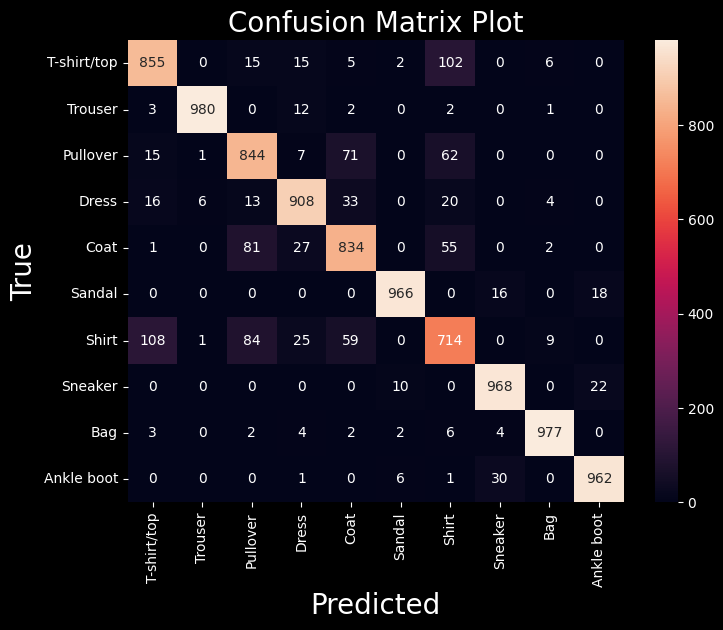

In [ ]:
# printing the classifcation report
report(history_adam_mlp, model_adam_mlp_eval, model_adam_mlp)

**Classification Report**
- Here we can observe the results more precisely for each category.
- Generally, we observe that some categories are more separable than others (e.g., Sandals), which makes sense since the algorithm finds it easier to distinguish a sandal from a t-shirt compared to a t-shirt and a pullover that may have similar shapes.

####MLP Using SGD as Optimizer


In [ ]:
# define the tuner
tuner_sgd = kt.BayesianOptimization(
    MyHyperModel(True, SGD),
    objective="val_accuracy",
    max_trials=10,
    overwrite=True
)

In [ ]:
# searching for the best model
tuner_sgd.search(X_train, Y_train, epochs=100, callbacks=[ReduceLROnPlateau(monitor='val_accuracy', patience=2, cooldown=2),tf.keras.callbacks.EarlyStopping('val_accuracy', patience=5,restore_best_weights=True)],validation_data=(X_dev,Y_dev))

Trial 10 Complete [00h 04m 24s]
val_accuracy: 0.8341666460037231

Best val_accuracy So Far: 0.859499990940094
Total elapsed time: 00h 45m 11s


In [ ]:
# summay of the best model
tuner_sgd.results_summary(1)

Results summary
Results in ./untitled_project
Showing 1 best trials
Objective(name="val_accuracy", direction="max")

Trial 00 summary
Hyperparameters:
hidden layers: 5
units of Dense-1: 256
kernel_initializer: glorot_uniform
activation_function: tanh
dropout_rate-1: 0.4
units of Dense-2: 256
dropout_rate-2: 0.2
output_activation_function: softmax
lr: 0.000716204284484251
units of Dense-3: 128
dropout_rate-3: 0.0
units of Dense-4: 128
dropout_rate-4: 0.0
units of Dense-5: 128
dropout_rate-5: 0.0
batch_size: 16
Score: 0.859499990940094


In [ ]:
# define the model with the best parameters after tuning process
best_hps_mlp_sgd = tuner_sgd.get_best_hyperparameters(num_trials=1)[0]

# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
model_sgd_mlp = tuner_sgd.hypermodel.build(best_hps_mlp_sgd)

history_sgd_mlp = model_sgd_mlp.fit(X_train, Y_train, epochs=100, batch_size = 16, callbacks=[ReduceLROnPlateau(monitor='val_accuracy', patience=2, cooldown=2),tf.keras.callbacks.EarlyStopping('val_accuracy', patience=5,restore_best_weights=True)], validation_data=(X_dev,Y_dev))

Epoch 1/100
3375/3375 [==============================] - 14s 4ms/step - loss: 1.2760 - accuracy: 0.5701 - val_loss: 0.8075 - val_accuracy: 0.7047 - lr: 7.1620e-04
Epoch 2/100
3375/3375 [==============================] - 13s 4ms/step - loss: 0.7893 - accuracy: 0.7183 - val_loss: 0.6610 - val_accuracy: 0.7563 - lr: 7.1620e-04
Epoch 3/100
3375/3375 [==============================] - 13s 4ms/step - loss: 0.6760 - accuracy: 0.7557 - val_loss: 0.5956 - val_accuracy: 0.7825 - lr: 7.1620e-04
Epoch 4/100
3375/3375 [==============================] - 12s 4ms/step - loss: 0.6196 - accuracy: 0.7763 - val_loss: 0.5554 - val_accuracy: 0.8002 - lr: 7.1620e-04
Epoch 5/100
3375/3375 [==============================] - 13s 4ms/step - loss: 0.5829 - accuracy: 0.7906 - val_loss: 0.5258 - val_accuracy: 0.8083 - lr: 7.1620e-04
Epoch 6/100
3375/3375 [==============================] - 13s 4ms/step - loss: 0.5552 - accuracy: 0.8010 - val_loss: 0.5065 - val_accuracy: 0.8155 - lr: 7.1620e-04
Epoch 7/100
3375/3375 

In [ ]:
# It can be used to reconstruct the model identically.
#model_sgd_mlp = keras.models.load_model("sgd_mlp_model")
model_sgd_mlp.summary()
#history_sgd_mlp = model_sgd_mlp.fit(X_train, Y_train, epochs=50, batch_size = 32, callbacks=[ReduceLROnPlateau(monitor='val_loss', patience=2, cooldown=2),tf.keras.callbacks.EarlyStopping('val_loss', patience=5,restore_best_weights=True)], validation_data=(X_dev,Y_dev))

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 784)]             0         
                                                                 
 Hidden-1 (Dense)            (None, 256)               200960    
                                                                 
 Dropout-1 (Dropout)         (None, 256)               0         
                                                                 
 Hidden-2 (Dense)            (None, 256)               65792     
                                                                 
 Dropout-2 (Dropout)         (None, 256)               0         
                                                                 
 Hidden-3 (Dense)            (None, 128)               32896     
                                                                 
 Dropout-3 (Dropout)         (None, 128)               0   

In [ ]:
val_acc_per_epoch_mlp_sgd = history_sgd_mlp.history['val_accuracy']
best_epoch_mlp_sgd = val_acc_per_epoch_mlp_sgd.index(max(val_acc_per_epoch_mlp_sgd)) + 1
print('Best epoch: %d' % (best_epoch_mlp_sgd,))

Best epoch: 18


In [ ]:
# evaluation of the final model
eval_result_mlp_sgd = model_sgd_mlp.evaluate(X_test, Y_test)

# cleaning up
clean_up(model_sgd_mlp)

313/313 [==============================] - 1s 2ms/step - loss: 0.4532 - accuracy: 0.8396


#### MLP Using SGD | Results
- We create an MLP using the SGD optimizer:
   - It does not perfom as good as our MLP with the Adam Optimizer.
   - We could have tried to improve our model by using more epochs as it seems that it does not converge during the first 100 epochs.
   - We could also have tried to improve the perfomance of our MLP model by adding more trials in our tuner search, more options in the activation functions and kernel initializer and by trying other opimizers, e.g., AdamW optimizer, which can combine the convergence benefits of both Adam and SGD in theory.

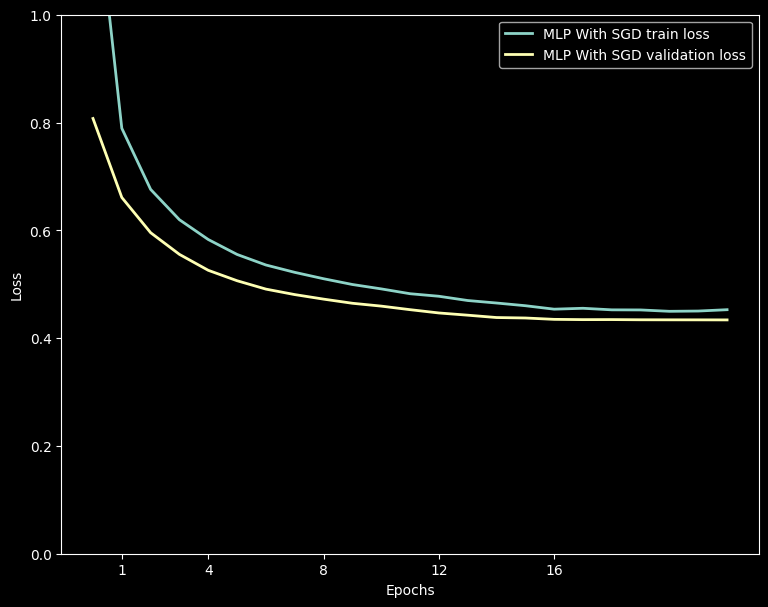

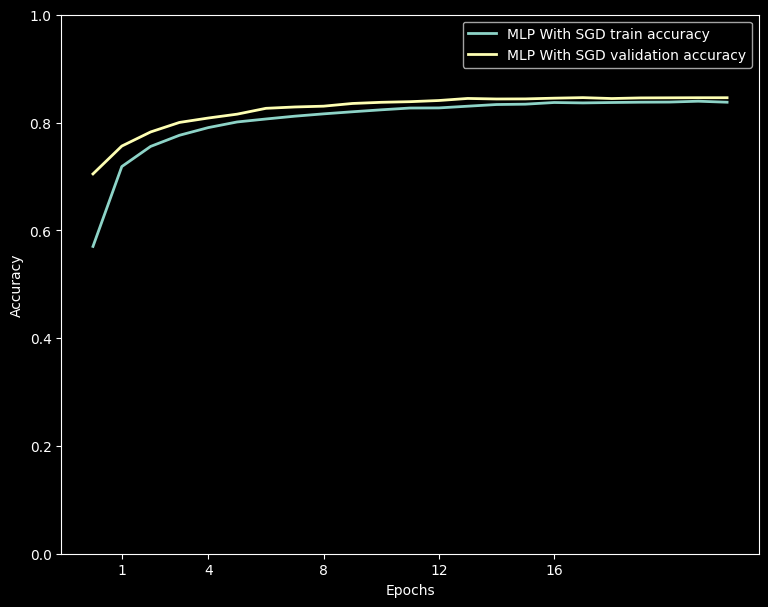

In [ ]:
# Plot train and validation error per epoch.
plot_history(hs={'MLP With SGD': history_sgd_mlp}, epochs=best_epoch_mlp_sgd, metric='loss')
plot_history(hs={'MLP With SGD': history_sgd_mlp}, epochs=best_epoch_mlp_sgd, metric='accuracy')

Train Loss     : 0.45273
Validation Loss: 0.43379
Test Loss      : 0.45324
---
Train Accuracy     : 0.83767
Validation Accuracy: 0.84600
Test Accuracy      : 0.83960

Precision, recall, F1 scores for each class (train set)
1688/1688 [==============================] - 3s 2ms/step
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      5373
           1       0.98      0.95      0.97      5425
           2       0.80      0.71      0.75      5413
           3       0.89      0.84      0.87      5381
           4       0.76      0.77      0.76      5399
           5       0.96      0.90      0.93      5431
           6       0.76      0.48      0.58      5386
           7       0.91      0.90      0.91      5407
           8       0.96      0.94      0.95      5385
           9       0.92      0.95      0.93      5400

   micro avg       0.88      0.83      0.85     54000
   macro avg       0.87      0.82      0.85     54000
weighted avg    

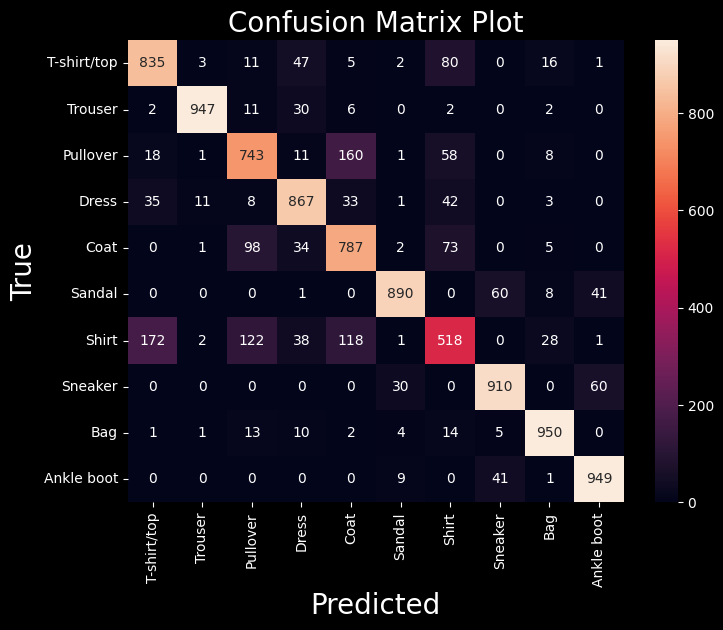

In [ ]:
# printing the classification report
report(history_sgd_mlp, eval_result_mlp_sgd, model_sgd_mlp)

**Classification Report**
- It is evident here that this model is certainly worse than the Adam MLP. Again it can be predict some categories well, like the Bag , but is is even worse in difficult categories like Shirt.
- More specifically there are many pullovers, Tshirt/tops and even Coats that are missclassified as Shirts as well as a lot of Shirts that are missclassified as the aforementioned categories.
- Furthermore there is another problem with the predictions that is not as evident as the previous one. That is the fact that some sandals, sneakers and ankle boots are geting missclassified. These predictions are not as problematic as the ones concern Shirts, but they are certainly worse than the adam MLP's.

## CNN

### Data Preprocessing
**Data**:
- The data are grayscale 28*28 images of fashion items
- We will use a CNN to classify them (no need to flatten as when using an MLP)
- The values of the inputs are in [0, 255] so we normalize them to [0, 1]

In [ ]:
# loading the data
classes = 10
(X_train_val, y_train_val), (X_test, y_test) = fashion_mnist.load_data()

# splitting the data
X_train, X_dev, y_train, y_dev = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=1888)

# reshaping the data
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_dev = X_dev.reshape(X_dev.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
X_train_val = X_train_val.reshape(X_train_val.shape[0], 28, 28, 1)

# changing the type of data set
X_train = X_train.astype('float32')
X_dev = X_dev.astype('float32')
X_test = X_test.astype('float32')
X_train_val = X_train_val.astype('float32')

# normilize the data
X_train /= 255
X_dev /= 255
X_test /= 255
X_train_val /= 255

# creating tone-hot vectors for labeled data
Y_train = to_categorical(y_train, classes)
Y_dev = to_categorical(y_dev, classes)
Y_test = to_categorical(y_test, classes)
Y_train_val = to_categorical(y_train_val, classes)

###CNN Creation

- We create a CNN as a class in order to pass the optimizer as an argument later as well as passing a boolean argument for the dropout layers. Also we can later control if we use Batch Normalization through a boolean argument.
- We use a Functional Model.
- In the architecture of our functional CNN we hypertune:
    - The number of hidden layers, their activation function the units number and the kernel initializer.
    - The dropout rate of every hidden layer.
    - The value of the learning rate.
    - The value of the batch size.
    - The kernel initializer of the output layer
- The basic architecture of our CNN was not hypertuned, e.g. , filters, kernel size, pool side etc.

In [ ]:
# Creating a class for CNN tuning
class MyCNNHyperModel(kt.HyperModel):
      # users' initial values
    def __init__(self, conv_dropout, optimizer, batch_norm):
        self.conv_dropout = conv_dropout
        self.optimizer = optimizer
        self.batch_norm = batch_norm
    # Define the CNN achitecture
    def build(self, hp):
        np.random.seed(1966)  # Define the seed for numpy to have reproducible experiments.
        set_seed(7)  # Define the seed for Tensorflow to have reproducible experiments.

        # Define the input layer.
        input = Input(shape=(28, 28, 1), name='Input')

        x = input
        # Define the convolutional layers.
        for i in range(hp.Int('convolutional_layers', 1, 3)):
            x = Conv2D(
                filters=8 * (2 ** i),
                kernel_size=(3, 3),
                strides=(1, 1),
                padding='same',
                dilation_rate=(1, 1),
                activation=hp.Choice('activation_function', ['swish', 'tanh', 'gelu']),
                kernel_initializer=hp.Choice('kernel_initializer', ['glorot_uniform', 'glorot_normal']),
                name='Conv2D-{0:d}-a'.format(i + 1)
            )(x)
            x = Conv2D(
                filters=8 * (2 ** i),
                kernel_size=(3, 3),
                strides=(1, 1),
                padding='same',
                dilation_rate=(1, 1),
                activation=hp.Choice('activation_function', ['swish', 'tanh', 'gelu']),
                kernel_initializer=hp.Choice('kernel_initializer', ['glorot_uniform', 'glorot_normal']),
                name='Conv2D-{0:d}-b'.format(i + 1)
            )(x)

            if self.batch_norm:
                x = BatchNormalization()(x)
            # Define the max-pooling layers.
            x = MaxPool2D(
                pool_size=(2, 2),
                strides=(2, 2),  # to change
                padding='same',
                name='MaxPool2D-{0:d}'.format(i + 1)
            )(x)
            # Dropout (TRUE or FALSE)
            if self.conv_dropout:
                x = Dropout(
                    rate=hp.Float('dropout_rate-{0:d}'.format(i + 1), 0, 0.6, step=0.2),
                    name='Dropout-{0:d}'.format(i + 1)
                )(x)

        # Flatten the convolved images so as to input them to a Dense Layer
        x = Flatten(name='Flatten')(x)

        # Define the output layer.
        output = Dense(
            units=classes,
            activation=hp.Choice('output_activation_function', ['softmax']),
            name='Output'
        )(x)

        # Define the model and compile it.
        model = Model(inputs=input, outputs=output)
        model.compile(optimizer=self.optimizer(learning_rate=hp.Float("lr", 0.00001, 0.001)),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
        return model
    # Batch size tuning
    def fit(self, hp, model, *args, **kwargs):
        return model.fit(
            *args,
            batch_size=hp.Choice("batch_size", [16, 32, 64, 128, 256]),
            **kwargs,
        )

###Using Adam with Batch Normalization



In [ ]:
# define the tuner
tuner_cnn_adam_with_Batch = kt.BayesianOptimization(
    MyCNNHyperModel(True,Adam,True),
    objective="val_accuracy",
    max_trials=10,
    overwrite=True
)

In [ ]:
# searching for the best model
tuner_cnn_adam_with_Batch.search(X_train, Y_train, epochs=100, callbacks=[ReduceLROnPlateau(monitor='val_accuracy', patience=5, cooldown=2),
                                                                         tf.keras.callbacks.EarlyStopping('val_accuracy', patience=5, restore_best_weights=True)],
                                                                         validation_data=(X_dev,Y_dev))

Trial 10 Complete [00h 01m 46s]
val_accuracy: 0.9163333177566528

Best val_accuracy So Far: 0.9273333549499512
Total elapsed time: 00h 49m 19s


In [ ]:
# summary of the best model
tuner_cnn_adam_with_Batch.results_summary(1)

Results summary
Results in ./untitled_project
Showing 1 best trials
Objective(name="val_accuracy", direction="max")

Trial 07 summary
Hyperparameters:
convolutional_layers: 3
activation_function: swish
kernel_initializer: glorot_normal
dropout_rate-1: 0.4
output_activation_function: softmax
lr: 0.00072163388010492
dropout_rate-2: 0.2
dropout_rate-3: 0.0
batch_size: 16
Score: 0.9273333549499512


In [ ]:
# define the model with the best parameters after tuning process
best_hps_cnn_adam_with_Batch = tuner_cnn_adam_with_Batch.get_best_hyperparameters(num_trials=1)[0]

# Build the model with the optimal hyperparameters and train it on the data for 100 epochs
model_adam_cnn_with_Batch = tuner_cnn_adam_with_Batch.hypermodel.build(best_hps_cnn_adam_with_Batch)

#model_adam_cnn_with_Batch.save("adam_cnn_model_with_Batch")
history_adam_cnn_with_Batch = model_adam_cnn_with_Batch.fit(X_train, Y_train, epochs=100,batch_size = 16 ,callbacks=[ReduceLROnPlateau(monitor='val_accuracy', patience=2, cooldown=2),tf.keras.callbacks.EarlyStopping('val_loss', patience=5,restore_best_weights=True)], validation_data=(X_dev,Y_dev))

Epoch 1/100
3375/3375 [==============================] - 29s 7ms/step - loss: 0.5530 - accuracy: 0.7949 - val_loss: 0.3678 - val_accuracy: 0.8627 - lr: 7.2163e-04
Epoch 2/100
3375/3375 [==============================] - 25s 7ms/step - loss: 0.3879 - accuracy: 0.8567 - val_loss: 0.3334 - val_accuracy: 0.8747 - lr: 7.2163e-04
Epoch 3/100
3375/3375 [==============================] - 25s 7ms/step - loss: 0.3357 - accuracy: 0.8753 - val_loss: 0.2769 - val_accuracy: 0.8985 - lr: 7.2163e-04
Epoch 4/100
3375/3375 [==============================] - 25s 7ms/step - loss: 0.3084 - accuracy: 0.8867 - val_loss: 0.2734 - val_accuracy: 0.8983 - lr: 7.2163e-04
Epoch 5/100
3375/3375 [==============================] - 25s 7ms/step - loss: 0.2919 - accuracy: 0.8931 - val_loss: 0.2700 - val_accuracy: 0.8982 - lr: 7.2163e-04
Epoch 6/100
3375/3375 [==============================] - 25s 7ms/step - loss: 0.2552 - accuracy: 0.9050 - val_loss: 0.2318 - val_accuracy: 0.9130 - lr: 7.2163e-05
Epoch 7/100
3375/3375 

In [ ]:
# summary of the best model
model_adam_cnn_with_Batch.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 28, 28, 1)]       0         
                                                                 
 Conv2D-1-a (Conv2D)         (None, 28, 28, 8)         80        
                                                                 
 Conv2D-1-b (Conv2D)         (None, 28, 28, 8)         584       
                                                                 
 batch_normalization_3 (Batc  (None, 28, 28, 8)        32        
 hNormalization)                                                 
                                                                 
 MaxPool2D-1 (MaxPooling2D)  (None, 14, 14, 8)         0         
                                                                 
 Dropout-1 (Dropout)         (None, 14, 14, 8)         0         
                                                           

In [ ]:
val_acc_per_epoch_cnn_adam_with_Batch = history_adam_cnn_with_Batch.history['val_accuracy']
best_epoch_cnn_adam_with_Batch = val_acc_per_epoch_cnn_adam_with_Batch.index(max(val_acc_per_epoch_cnn_adam_with_Batch)) + 1
print('Best epoch: %d' % (best_epoch_cnn_adam_with_Batch,))

Best epoch: 21


In [ ]:
# evaluation of the final model
eval_result_cnn_adam_with_Batch = model_adam_cnn_with_Batch.evaluate(X_test, Y_test)

# cleaning up
clean_up(hypermodel_cnn_adam_with_Batch)

313/313 [==============================] - 2s 4ms/step - loss: 0.2372 - accuracy: 0.9116


### Results
- Firstly, we create a CNN using Adam optimizer. In general, for our CNN's we only used Adam Optimizer, since in comparison with other optimizers has better performance as we saw in our first approach on MLPs.
   - We also add in this CNN Batch Normalization. We observed that without batch normilization our model seems to have **slightly**  better performance on the test set.

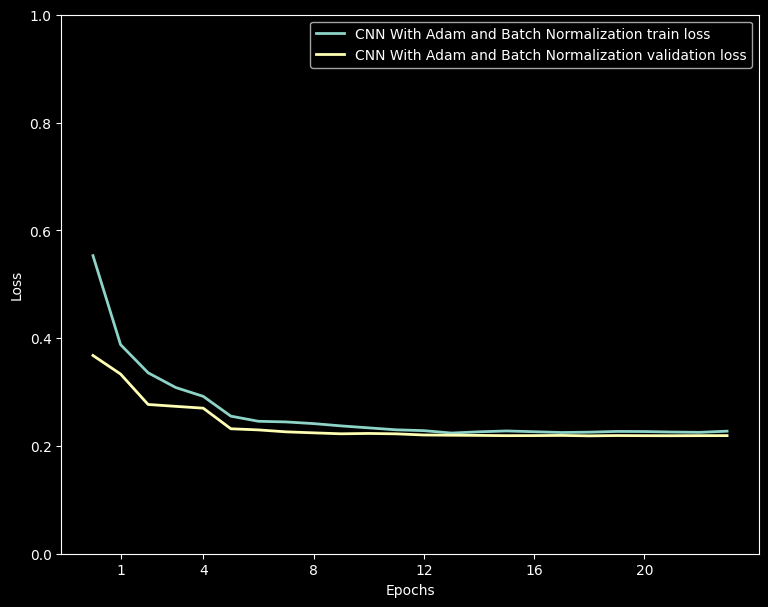

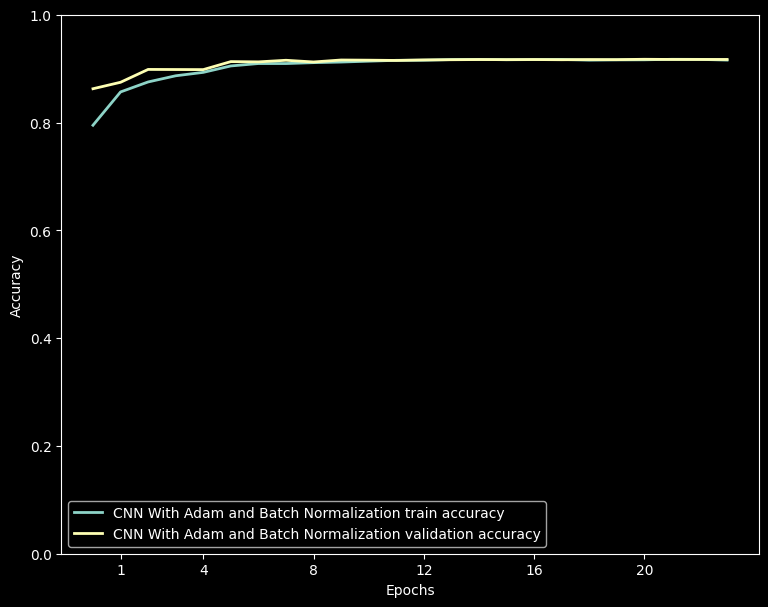

In [ ]:
# Plot train and validation error per epoch.
plot_history(hs={'CNN With Adam and Batch Normalization': history_adam_cnn_with_Batch}, epochs=best_epoch_cnn_adam_with_Batch, metric='loss')
plot_history(hs={'CNN With Adam and Batch Normalization': history_adam_cnn_with_Batch}, epochs=best_epoch_cnn_adam_with_Batch, metric='accuracy')

**Learning curves**
- Here we can also see that the train curve flattens as the epochs increase and the validation curve is again slightly better than the train one. This likely happens due to the fact that we used batch normalization, as this is not happens in our next approach where using no batch normalization.

Train Loss     : 0.22733
Validation Loss: 0.21914
Test Loss      : 0.23718
---
Train Accuracy     : 0.91587
Validation Accuracy: 0.91700
Test Accuracy      : 0.91160

Precision, recall, F1 scores for each class (train set)
1688/1688 [==============================] - 4s 3ms/step
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      5398
           1       0.99      0.99      0.99      5405
           2       0.92      0.87      0.90      5407
           3       0.95      0.92      0.94      5397
           4       0.89      0.89      0.89      5388
           5       0.99      0.99      0.99      5424
           6       0.82      0.79      0.81      5398
           7       0.97      0.98      0.97      5385
           8       1.00      0.99      0.99      5386
           9       0.98      0.98      0.98      5412

   micro avg       0.94      0.93      0.93     54000
   macro avg       0.94      0.93      0.93     54000
weighted avg    

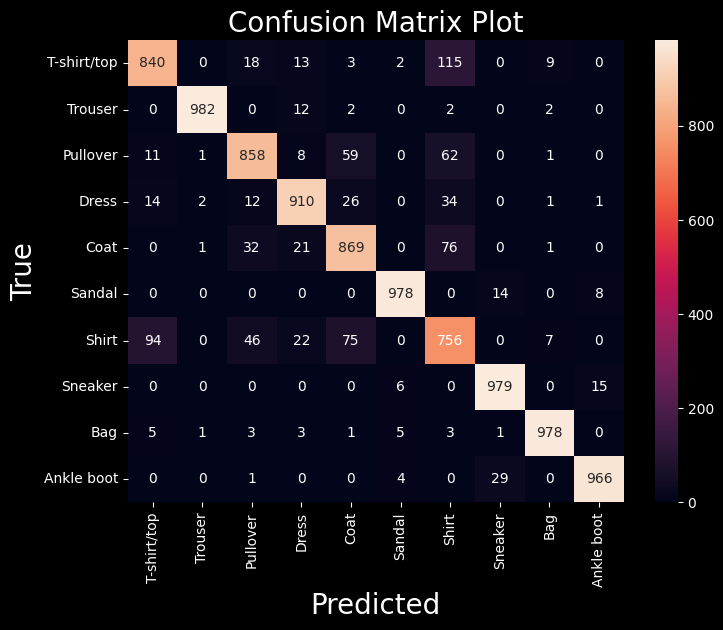

In [ ]:
# reporting
report(history_adam_cnn_with_Batch, eval_result_cnn_adam_with_Batch, model_adam_cnn_with_Batch)

**Classification Report**
-Regarding the performance of the CNN using Batch Normalization, we can see that the results are similar to the Adam's MLP, meaning that again T-shirts, shirts and coats predictions are getting mixed. But the overall test acuracy is consistently higher 91% .

###Using Adam without Batch Normalization

In [ ]:
# define the tuner
tuner_cnn_adam_No_Batch = kt.BayesianOptimization(
    MyCNNHyperModel(True,Adam,False),
    objective="val_accuracy",
    max_trials=10,
    overwrite=True
)

In [ ]:
# searching for the best model
tuner_cnn_adam_No_Batch.search(X_train, Y_train, epochs=100,
                               callbacks=[ReduceLROnPlateau(monitor='val_accuracy', patience=2, cooldown=2),
                                          tf.keras.callbacks.EarlyStopping('val_accuracy', patience=5,restore_best_weights=True)],
                               validation_data=(X_dev,Y_dev))

Trial 10 Complete [00h 10m 34s]
val_accuracy: 0.9125000238418579

Best val_accuracy So Far: 0.9154999852180481
Total elapsed time: 00h 44m 31s


In [ ]:
# summay of the best model
tuner_cnn_adam_No_Batch.results_summary(1)

Results summary
Results in ./untitled_project
Showing 1 best trials
Objective(name="val_accuracy", direction="max")

Trial 08 summary
Hyperparameters:
convolutional_layers: 3
activation_function: tanh
kernel_initializer: glorot_uniform
dropout_rate-1: 0.0
output_activation_function: softmax
lr: 0.0009798542440607465
batch_size: 16
dropout_rate-2: 0.2
dropout_rate-3: 0.4
Score: 0.9154999852180481


In [ ]:
# define the model with the best parameters after tuning process
best_hps_cnn_adam_No_Batch = tuner_cnn_adam_No_Batch.get_best_hyperparameters(num_trials=1)[0]
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
model_adam_cnn_No_Batch = tuner_cnn_adam_No_Batch.hypermodel.build(best_hps_cnn_adam_No_Batch)
#model_adam_cnn_No_Batch.save("adam_cnn_model_No_Batch")
history_adam_cnn_No_Batch = model_adam_cnn_No_Batch.fit(X_train, Y_train, batch_size= 16 ,epochs=100,
                                                        callbacks=[ReduceLROnPlateau(monitor='val_accuracy', patience=2, cooldown=2),
                                                                   tf.keras.callbacks.EarlyStopping('val_accuracy', patience=5,restore_best_weights=True)],
                                                        validation_data=(X_dev,Y_dev))

Epoch 1/100
3375/3375 [==============================] - 22s 6ms/step - loss: 0.5232 - accuracy: 0.8079 - val_loss: 0.3597 - val_accuracy: 0.8680 - lr: 9.7985e-04
Epoch 2/100
3375/3375 [==============================] - 20s 6ms/step - loss: 0.3854 - accuracy: 0.8608 - val_loss: 0.3149 - val_accuracy: 0.8852 - lr: 9.7985e-04
Epoch 3/100
3375/3375 [==============================] - 18s 5ms/step - loss: 0.3539 - accuracy: 0.8717 - val_loss: 0.3110 - val_accuracy: 0.8868 - lr: 9.7985e-04
Epoch 4/100
3375/3375 [==============================] - 19s 6ms/step - loss: 0.3383 - accuracy: 0.8793 - val_loss: 0.2978 - val_accuracy: 0.8972 - lr: 9.7985e-04
Epoch 5/100
3375/3375 [==============================] - 19s 6ms/step - loss: 0.3273 - accuracy: 0.8834 - val_loss: 0.2887 - val_accuracy: 0.8942 - lr: 9.7985e-04
Epoch 6/100
3375/3375 [==============================] - 19s 6ms/step - loss: 0.3189 - accuracy: 0.8859 - val_loss: 0.2850 - val_accuracy: 0.8987 - lr: 9.7985e-04
Epoch 7/100
3375/3375 

In [ ]:
# summary of the best model
model_adam_cnn_No_Batch.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 28, 28, 1)]       0         
                                                                 
 Conv2D-1-a (Conv2D)         (None, 28, 28, 8)         80        
                                                                 
 Conv2D-1-b (Conv2D)         (None, 28, 28, 8)         584       
                                                                 
 MaxPool2D-1 (MaxPooling2D)  (None, 14, 14, 8)         0         
                                                                 
 Dropout-1 (Dropout)         (None, 14, 14, 8)         0         
                                                                 
 Conv2D-2-a (Conv2D)         (None, 14, 14, 16)        1168      
                                                                 
 Conv2D-2-b (Conv2D)         (None, 14, 14, 16)        2320

In [ ]:
val_acc_per_epoch_cnn_adam_No_Batch = history_adam_cnn_No_Batch.history['val_accuracy']
best_epoch_cnn_adam_No_Batch = val_acc_per_epoch_cnn_adam_No_Batch.index(max(val_acc_per_epoch_cnn_adam_No_Batch)) + 1
print('Best epoch: %d' % (best_epoch_cnn_adam_No_Batch,))

Best epoch: 25


In [ ]:
# evaluation of the final model
eval_result_cnn_adam_No_Batch = model_adam_cnn_No_Batch.evaluate(X_test, Y_test)

# cleaning up
clean_up(model_adam_cnn_No_Batch)

313/313 [==============================] - 1s 4ms/step - loss: 0.2356 - accuracy: 0.9161


### Results

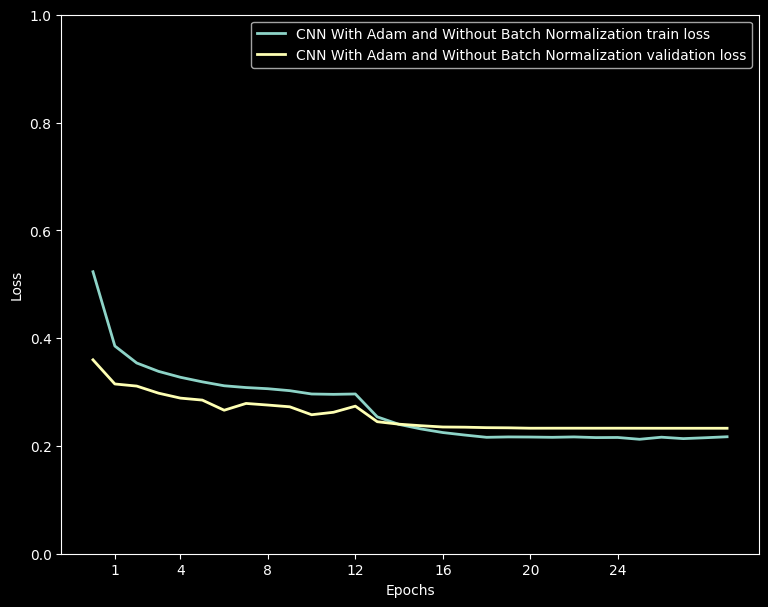

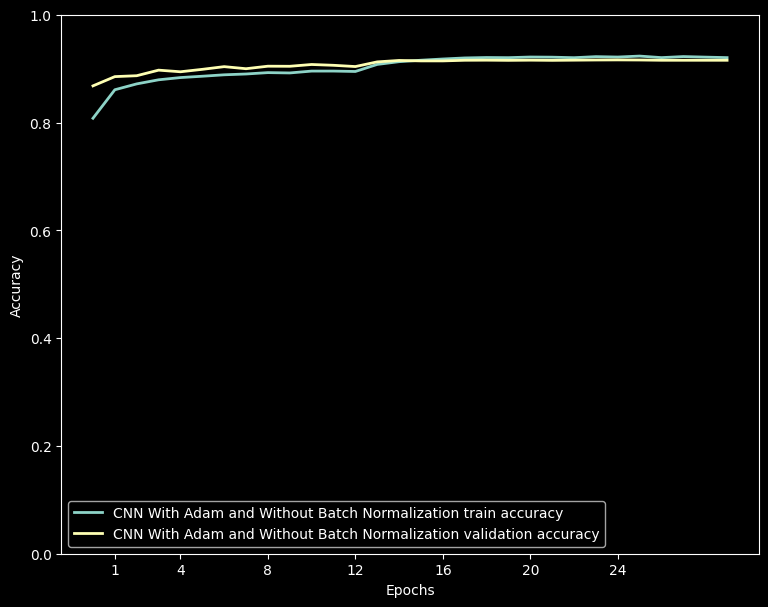

In [ ]:
# Plot train and validation error per epoch.
plot_history(hs={'CNN With Adam and Without Batch Normalization': history_adam_cnn_No_Batch}, epochs=best_epoch_cnn_adam_No_Batch, metric='loss')
plot_history(hs={'CNN With Adam and Without Batch Normalization': history_adam_cnn_No_Batch}, epochs=best_epoch_cnn_adam_No_Batch, metric='accuracy')

**Learning curves**
- Here we can see that both line stabilize and are very close, with the train loss being lower than the validation during later epochs.
- A similar conclusion can be seen on the second plot where the train accuracy is slightly higher than the validation one.

Train Loss     : 0.21700
Validation Loss: 0.23277
Test Loss      : 0.23555
---
Train Accuracy     : 0.92041
Validation Accuracy: 0.91550
Test Accuracy      : 0.91610

Precision, recall, F1 scores for each class (train set)
1688/1688 [==============================] - 3s 2ms/step
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      5373
           1       1.00      0.99      1.00      5425
           2       0.91      0.90      0.91      5413
           3       0.95      0.94      0.94      5381
           4       0.90      0.89      0.89      5399
           5       1.00      0.99      0.99      5431
           6       0.86      0.78      0.82      5386
           7       0.97      0.99      0.98      5407
           8       1.00      0.99      0.99      5385
           9       0.99      0.98      0.98      5400

   micro avg       0.95      0.93      0.94     54000
   macro avg       0.95      0.93      0.94     54000
weighted avg    

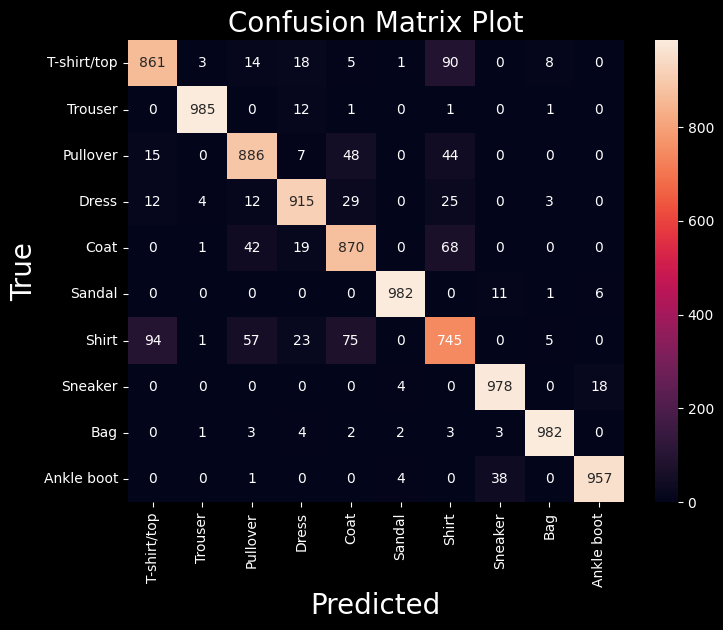

In [ ]:
# printing the classification report
report(history_adam_cnn_No_Batch, eval_result_cnn_adam_No_Batch, model_adam_cnn_No_Batch)

**Classification report:**
The CNN without batch normalization performs almost identically as the earlier one (with batch normalization). Overall, we cannot say with certainty that the differences between the 2 CNN's predictions are significant.


Through various attempts we can safely assume that the most important things to tune (which had a significant difference to our scores) were the batch size and the learning rate as well as the optimizer. As a result we would like to try different values for the first two and also different optimizers to try solve the problem with better results.